#🏥Diabetes Prediction : Using ML Algorithms

#🚀Objective
**This notebook presents an end-to-end machine learning workflow for diabetes prediction,incorporating feature engineering,data cleaning and analysis,model training, and evaluation using health and lifestyle indictors. The analysis focuses on building and accessing predictive models for identifying patterns associated  with diabetes risk in the dataset and generate data-driven insights**.

1. **Importing the required packages**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from imblearn.over_sampling import SMOTENC
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report,precision_score,recall_score,f1_score
from sklearn.metrics import roc_auc_score , average_precision_score , confusion_matrix
from scipy.stats import uniform,randint

In [3]:
df = pd.read_csv('/content/sample_data/diabetes_prediction_dataset.csv.zip')

In [4]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [5]:
df.shape

(100000, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


2. **Exploratory Data Analysis and Feature Engineering**

In [7]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [8]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


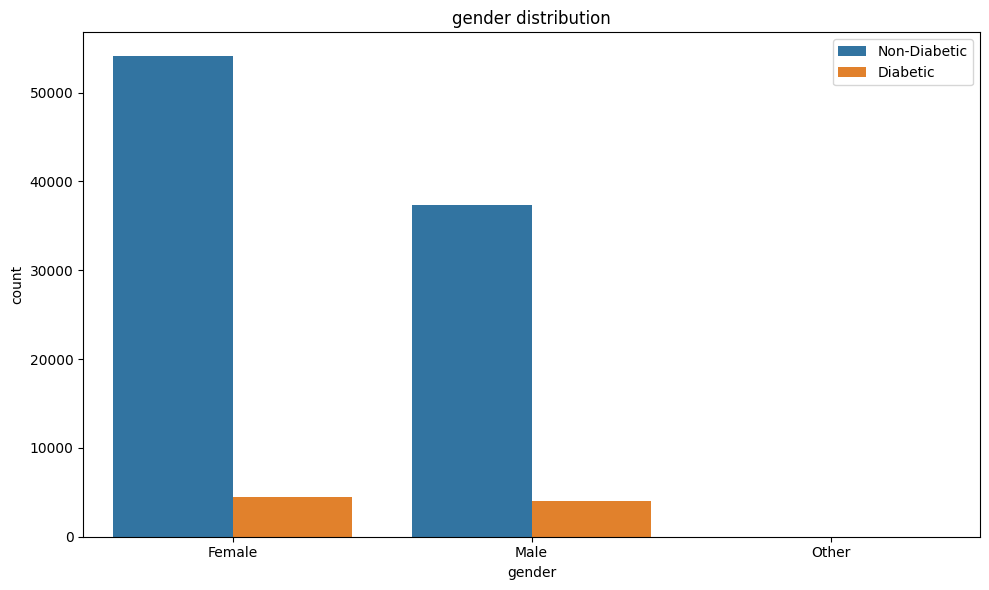

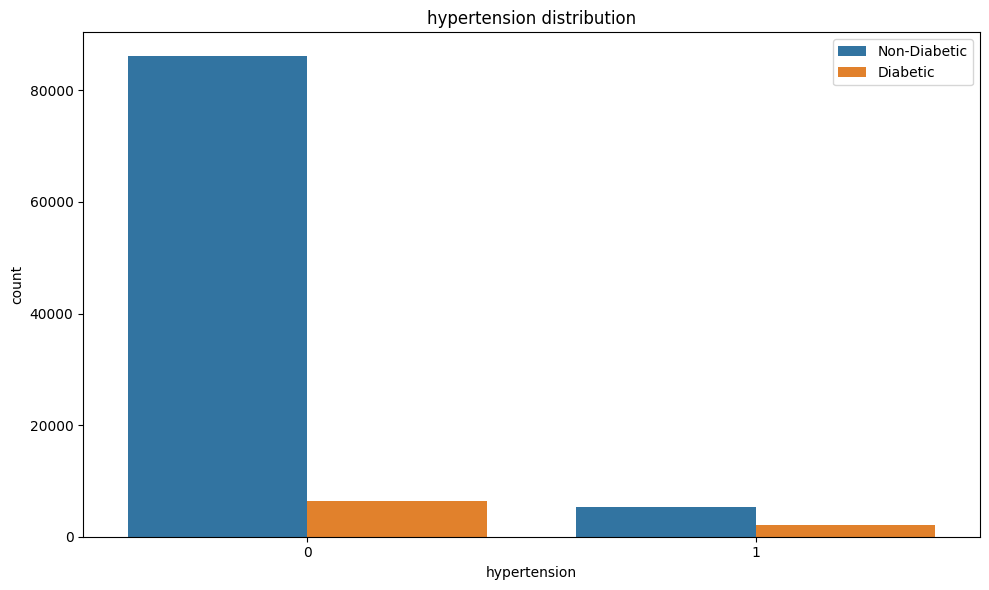

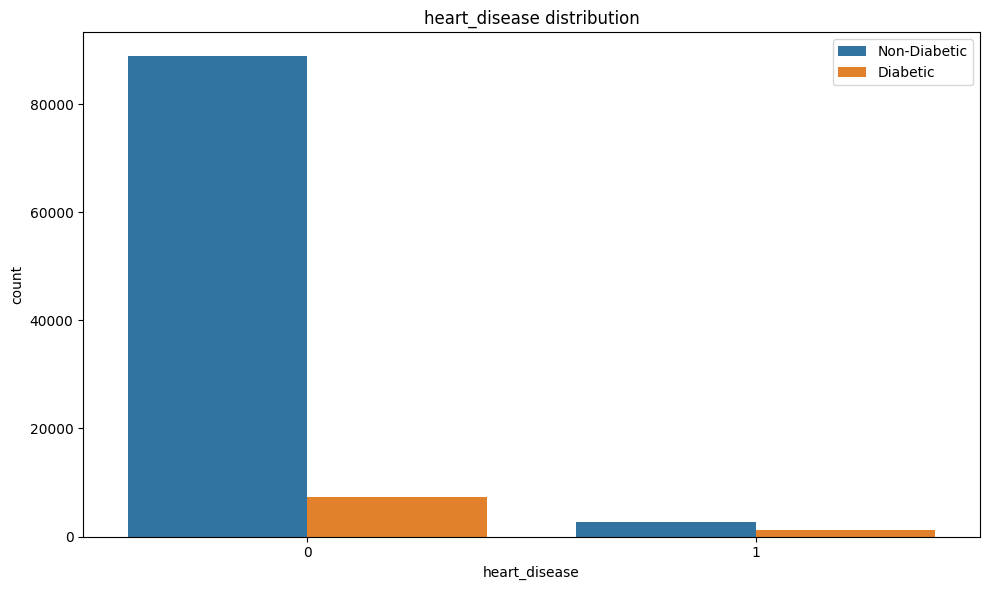

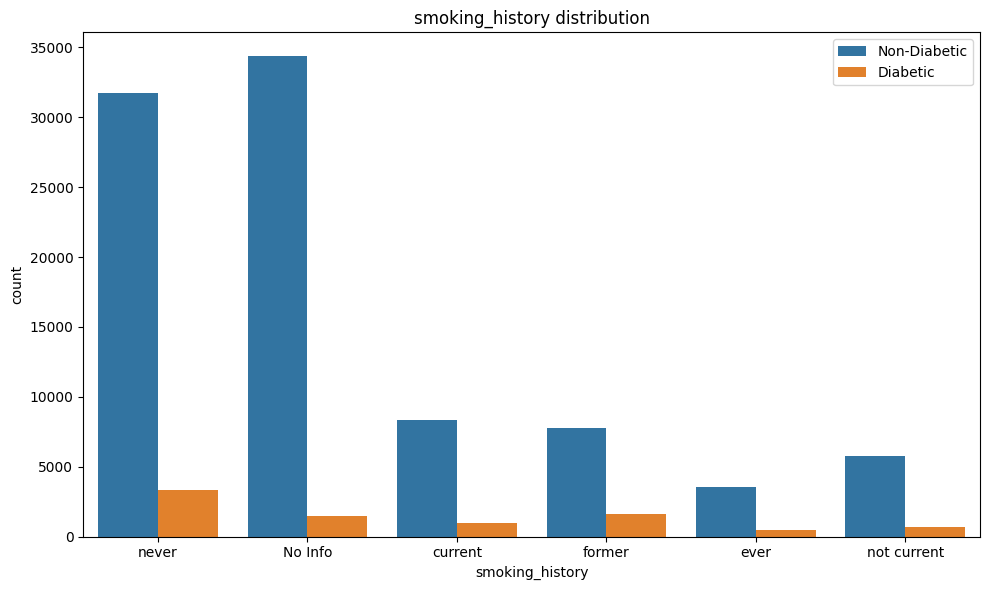

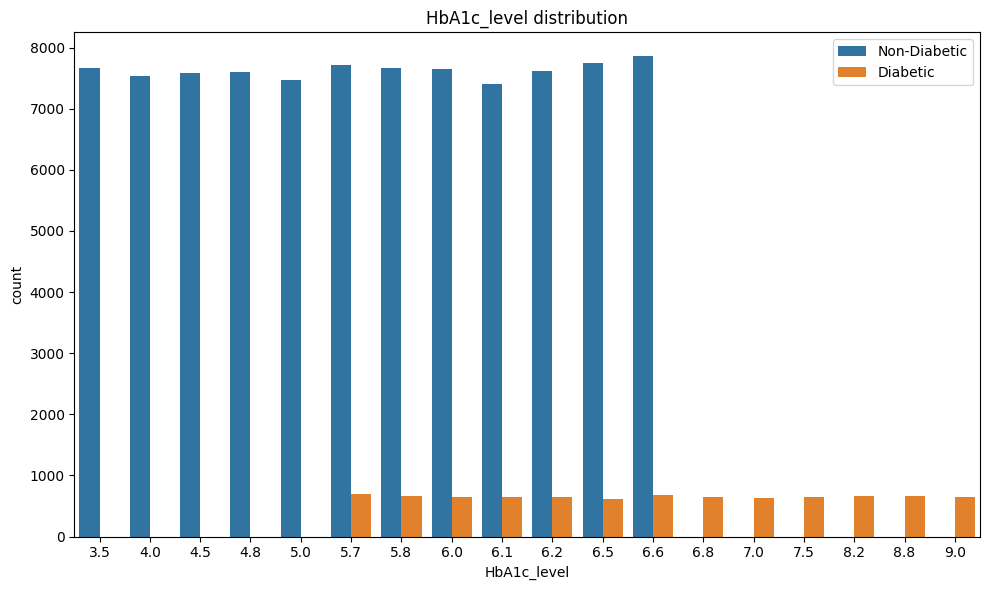

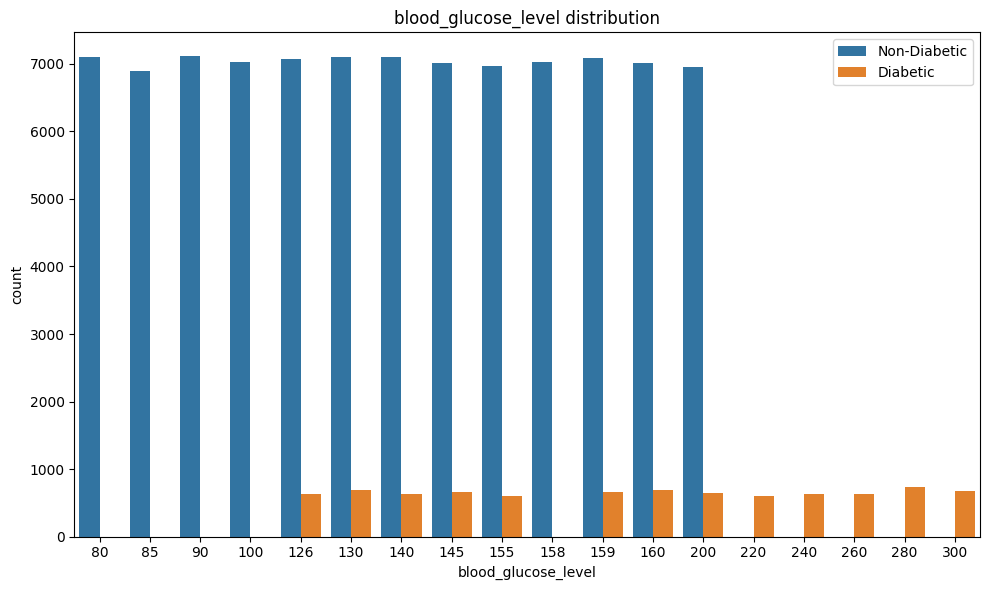

In [9]:
cols = ([i for i in df.columns if (i != 'diabetes' and i != 'age' and i != 'bmi')])
for col in cols :
  plt.figure(figsize=(10,6))
  sns.countplot(data = df , x = col , hue = 'diabetes')
  plt.title(f"{col} distribution")
  plt.legend(labels=['Non-Diabetic','Diabetic'])
  plt.tight_layout()

3. **Feature Engineering & Data Preprocessing**

    Diabetes risk models highly benefit from-:
    
    * **Glucose-Age Interaction** : older + higher Glucose = high risk

    * **Risk Score** : Higher the risk score, higher the chance of a person being diabetic

In [10]:
df['GlucoseAge'] = df['age'] * df['blood_glucose_level']
df['Risk_score'] = (
    (df['bmi'] > 30).astype(int) +
    (df['age'] > 45).astype(int) +
    (df['HbA1c_level'] > 6.5).astype(int) +
    (df['blood_glucose_level'] > 140).astype(int) + df['heart_disease'] + df['hypertension']
)

In [11]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,GlucoseAge,Risk_score
0,Female,80.0,0,1,never,25.19,6.6,140,0,11200.0,3
1,Female,54.0,0,0,No Info,27.32,6.6,80,0,4320.0,2
2,Male,28.0,0,0,never,27.32,5.7,158,0,4424.0,1
3,Female,36.0,0,0,current,23.45,5.0,155,0,5580.0,1
4,Male,76.0,1,1,current,20.14,4.8,155,0,11780.0,4
...,...,...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0,7200.0,1
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0,200.0,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0,10230.0,2
99998,Female,24.0,0,0,never,35.42,4.0,100,0,2400.0,1


/tmp/ipykernel_23988/3779728496.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['GlucoseAge'])


Text(0.5, 1.0, 'Glucose-Age Distribution')

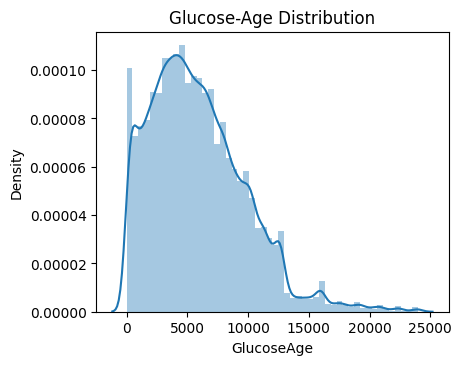

In [12]:
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.distplot(df['GlucoseAge'])
plt.title('Glucose-Age Distribution')

/tmp/ipykernel_23988/2736741510.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'])
/tmp/ipykernel_23988/2736741510.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bmi'])
/tmp/ipykernel_23988/2736741510.py:9: UserWarning: 

`distplot` is a deprecated function and will be remov

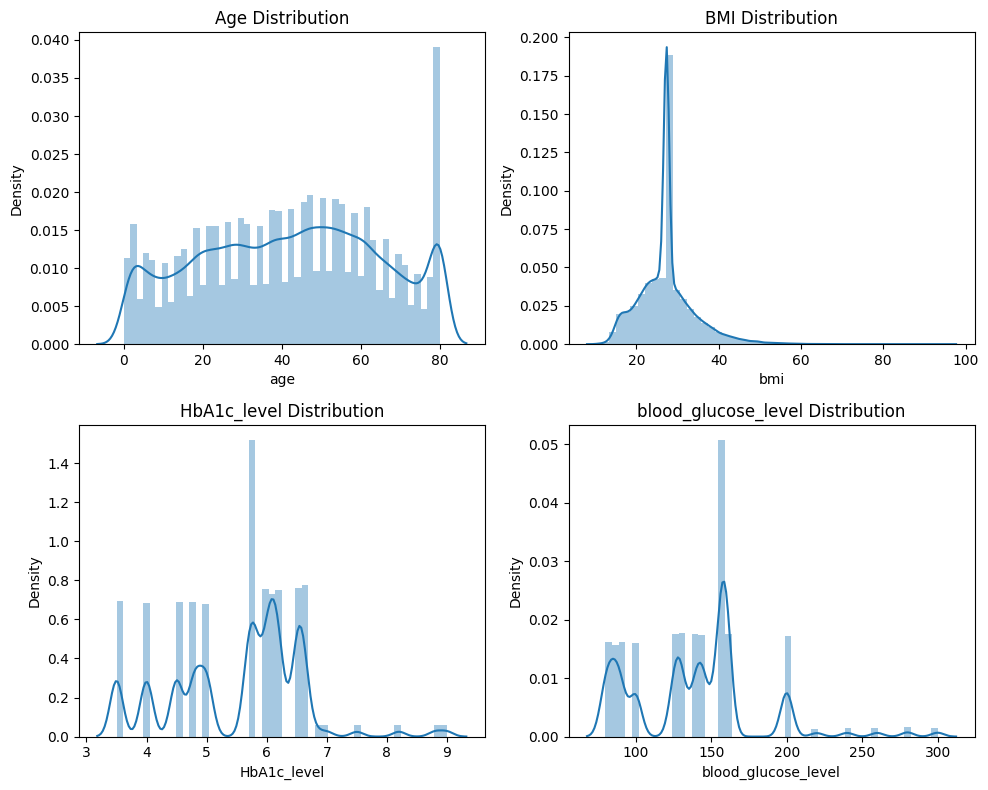

In [13]:
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.distplot(df['age'])
plt.title('Age Distribution')
plt.subplot(2,2,2)
sns.distplot(df['bmi'])
plt.title('BMI Distribution')
plt.subplot(2,2,3)
sns.distplot(df['HbA1c_level'])
plt.title('HbA1c_level Distribution')
plt.subplot(2,2,4)
sns.distplot(df['blood_glucose_level'])
plt.title('blood_glucose_level Distribution')
plt.tight_layout()
plt.show()

In [14]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,GlucoseAge,Risk_score
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000,5884.123263,1.420960
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883,3928.271099,1.115359
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000,6.400000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000,2940.000000,1.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000,5330.000000,1.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000,8200.000000,2.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000,24000.000000,6.000000


4. **Handling Outliers**

In [15]:
print(f"BMI Feature Skewness : {df['bmi'].skew()}")
print(f"Age Feature Skewness : {df['age'].skew()}")
print(f"HbA1c_level Feature Skewness : {df['HbA1c_level'].skew()}")
print(f"blood_glucose_level Feature Skewness : {df['blood_glucose_level'].skew()}")
print(f"Glucose-Age Feature Skewness : {df['GlucoseAge'].skew()}")

BMI Feature Skewness : 1.0438355183081105
Age Feature Skewness : -0.05197899678256747
HbA1c_level Feature Skewness : -0.0668537611478635
blood_glucose_level Feature Skewness : 0.8216549517517585
Glucose-Age Feature Skewness : 0.9258180631422172


BMI is highly right skewed whereas Glucose-Age is moderately skewed

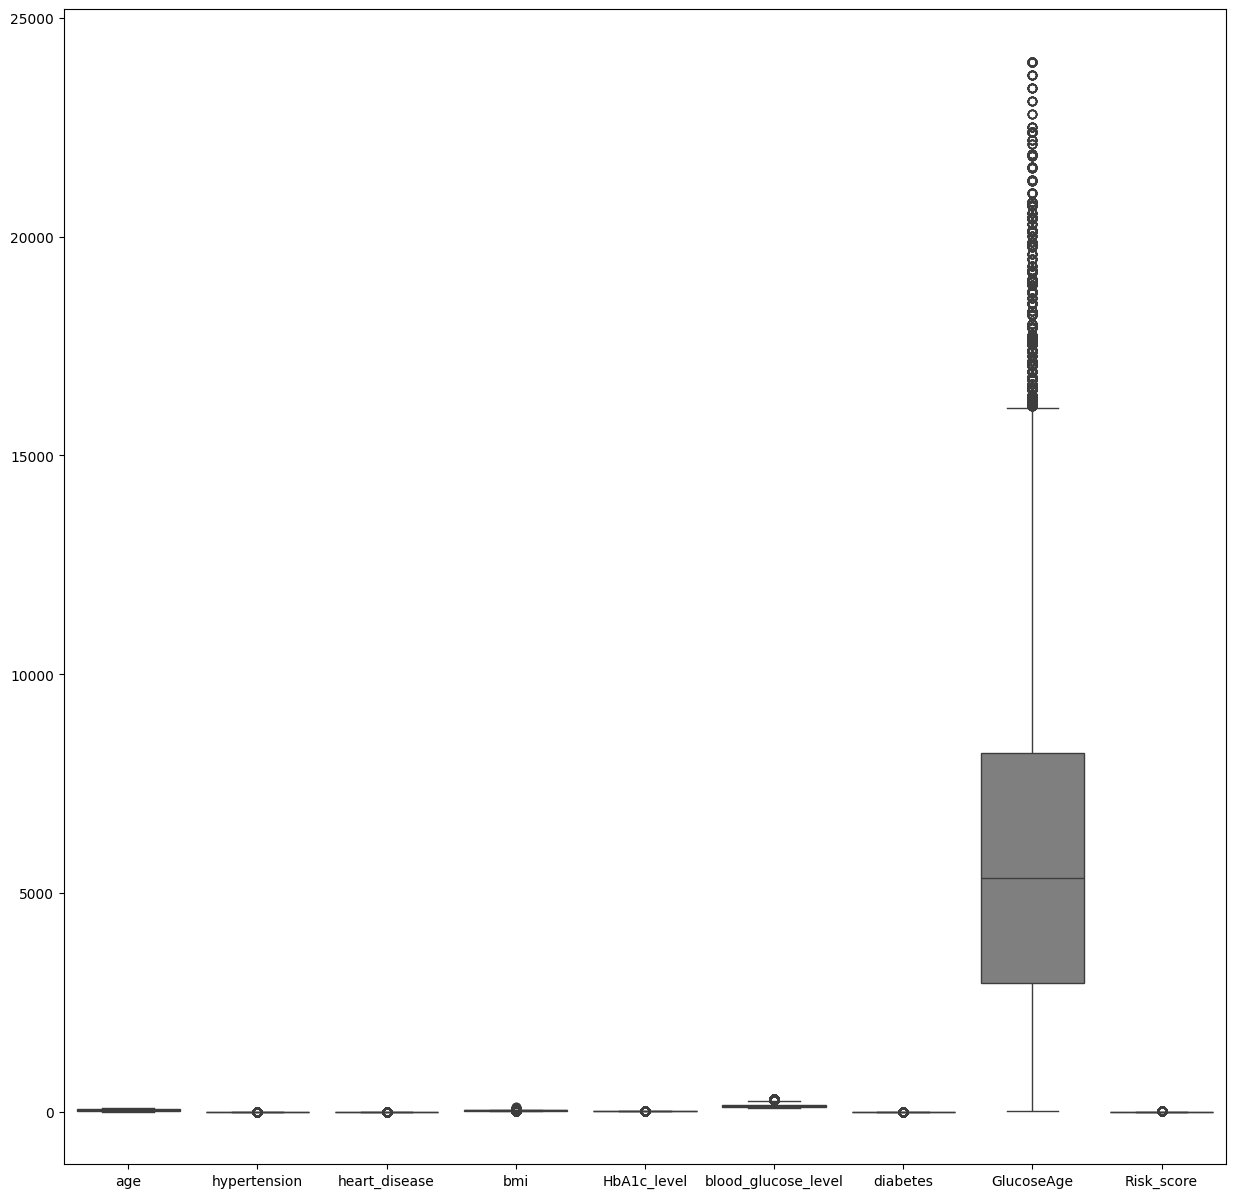

In [16]:
fig,ax = plt.subplots(figsize=(15,15))
sns.boxplot(data=df)
plt.show()

In [17]:
df['bmi'] = np.log1p(df['bmi'])
df['GlucoseAge'] = np.log1p(df['GlucoseAge'])
print(f"BMI Transformed Skewness : {df['bmi'].skew()}")
print(f"GlucoseAge Transformed Skewness : {df['GlucoseAge'].skew()}")

BMI Transformed Skewness : -0.10030590204416767
GlucoseAge Transformed Skewness : -1.6634865791400113


In [18]:
features = ['bmi','GlucoseAge']
for feature in features :
  print(f"{feature} Statistical Values After Log Transformation :")
  print(f"max = {df[feature].max()}")
  print(f"min = {df[feature].min()}")
  print(f"mean = {df[feature].mean()}")
  print(f"median = {df[feature].median()}")
  print(f"Standard Deviation = {df[feature].std()}")
  print("\n")

bmi Statistical Values After Log Transformation :
max = 4.5715099844954565
min = 2.3988039507345884
mean = 3.317219955426433
median = 3.343568268825519
Standard Deviation = 0.2300400805602167


GlucoseAge Statistical Values After Log Transformation :
max = 10.085850775128717
min = 2.0014800002101243
mean = 8.35032368398904
median = 8.581294116822761
Standard Deviation = 1.0014293704700081




In [19]:
print(df['smoking_history'].nunique())


6


5. **Feature Correlations**

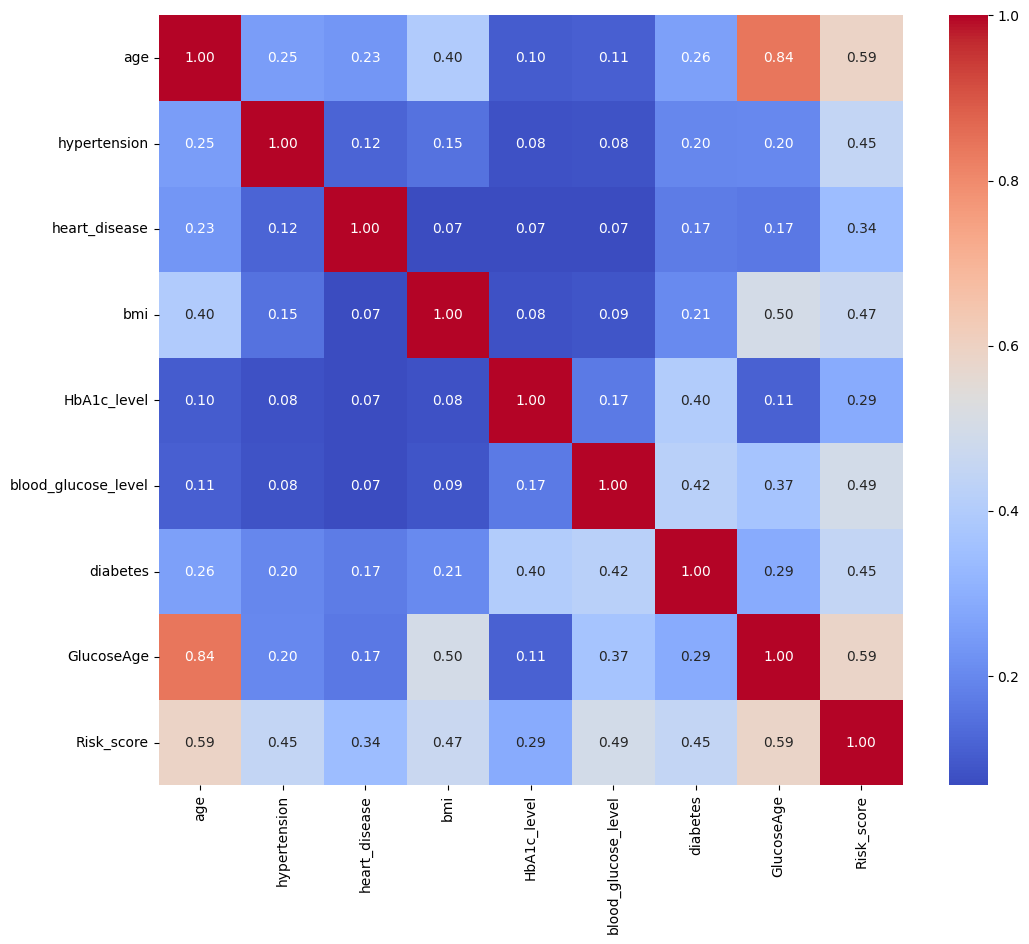

In [20]:
plt.figure(figsize=(12,10))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt=".2f")
plt.show()

In [21]:
df1 = df.copy()
df1

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,GlucoseAge,Risk_score
0,Female,80.0,0,1,never,3.265378,6.6,140,0,9.323758,3
1,Female,54.0,0,0,No Info,3.343568,6.6,80,0,8.371242,2
2,Male,28.0,0,0,never,3.343568,5.7,158,0,8.395026,1
3,Female,36.0,0,0,current,3.196630,5.0,155,0,8.627123,1
4,Male,76.0,1,1,current,3.051167,4.8,155,0,9.374243,4
...,...,...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,3.343568,6.2,90,0,8.881975,1
99996,Female,2.0,0,0,No Info,2.910719,6.5,100,0,5.303305,0
99997,Male,66.0,0,0,former,3.361417,5.7,155,0,9.233178,2
99998,Female,24.0,0,0,never,3.595118,4.0,100,0,7.783641,1


# 📖**Version-A : Using SMOTE-NC (Synthetic Oversampling)**

6. **Spltting the data for training and testing**

In [ ]:
X = df.drop('diabetes',axis=1)
Y = df['diabetes']

In [ ]:
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
X_train

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,GlucoseAge,Risk_score
75220,Male,73.0,0,0,former,3.249211,3.5,80,8.672657,1
48955,Male,80.0,0,0,never,3.242592,5.7,145,9.358847,2
44966,Female,38.0,0,0,ever,3.231989,4.0,158,8.700348,1
13568,Female,26.0,0,0,not current,2.989211,5.0,100,7.863651,0
92727,Female,61.0,1,0,current,3.140265,4.5,85,8.553718,2
...,...,...,...,...,...,...,...,...,...,...
6265,Male,49.0,0,0,never,3.525772,5.7,80,8.274102,2
54886,Female,15.0,0,0,never,3.370738,5.0,159,7.777374,1
76820,Male,42.0,0,0,never,3.301009,5.8,85,8.180601,0
860,Female,37.0,0,0,never,3.256557,6.2,158,8.673684,1


In [ ]:
Y_train.value_counts()

,count
diabetes,
0,73208
1,6792


In [ ]:
num = ['age','bmi','HbA1c_level','blood_glucose_level','GlucoseAge']

**Normalization of Numeric features**

In [ ]:
scaler = StandardScaler()
X_train[num] = scaler.fit_transform(X_train[num])
X_test[num] = scaler.transform(X_test[num])

In [ ]:
X_train

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,GlucoseAge,Risk_score
75220,Male,1.378720,0,0,former,-0.297653,-1.892451,-1.425157,0.318960,1
48955,Male,1.689866,0,0,never,-0.326481,0.162169,0.170591,1.006441,2
44966,Female,-0.177011,0,0,ever,-0.372662,-1.425492,0.489740,0.346703,1
13568,Female,-0.710404,0,0,not current,-1.430088,-0.491574,-0.934157,-0.491568,0
92727,Female,0.845326,1,0,current,-0.772168,-0.958533,-1.302407,0.199797,2
...,...,...,...,...,...,...,...,...,...,...
6265,Male,0.311933,0,0,never,0.906915,0.162169,-1.425157,-0.080345,2
54886,Female,-1.199348,0,0,never,0.231661,-0.491574,0.514290,-0.578008,1
76820,Male,0.000787,0,0,never,-0.072047,0.255561,-1.302407,-0.174022,0
860,Female,-0.221460,0,0,never,-0.265658,0.629128,0.489740,0.319989,1


In [ ]:
cat = ['gender','smoking_history','hypertension','heart_disease']
col = [X_train.columns.get_loc(i) for i in cat]
print(col)

[0, 4, 2, 3]


**Handling Imbalanced data and categorical data** **using SMOTE-NC(for categorical data)**

In [ ]:
smote_nc = SMOTENC(categorical_features=col,sampling_strategy=0.35,random_state=42)
X_train_res,Y_train_res = smote_nc.fit_resample(X_train,Y_train)

In [ ]:
X_train_res.shape

(98830, 10)

In [ ]:
Y_train_res.value_counts()

,count
diabetes,
0,73208
1,25622


In [ ]:
categorical_cols = ['gender','smoking_history']

**Encoding Technique for Categorical data**

In [ ]:
processor = ColumnTransformer(
    transformers = [
        ('encoder',OneHotEncoder(sparse_output=False,handle_unknown='ignore',drop='first'),categorical_cols)
    ],
    remainder = 'passthrough'
)

In [ ]:
X_train_final = processor.fit_transform(X_train_res)
X_test_final = processor.transform(X_test)

In [ ]:
names = processor.get_feature_names_out()
X_train_new = pd.DataFrame(X_train_final,columns=names,index=Y_train_res.index)
X_test_new = pd.DataFrame(X_test_final,columns=names,index=X_test.index)

In [ ]:
X_train_new

,encoder__gender_Male,encoder__gender_Other,encoder__smoking_history_current,encoder__smoking_history_ever,encoder__smoking_history_former,encoder__smoking_history_never,encoder__smoking_history_not current,remainder__age,remainder__hypertension,remainder__heart_disease,remainder__bmi,remainder__HbA1c_level,remainder__blood_glucose_level,remainder__GlucoseAge,remainder__Risk_score
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.378720,0.0,0.0,-0.297653,-1.892451,-1.425157,0.318960,1.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.689866,0.0,0.0,-0.326481,0.162169,0.170591,1.006441,2.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.177011,0.0,0.0,-0.372662,-1.425492,0.489740,0.346703,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.710404,0.0,0.0,-1.430088,-0.491574,-0.934157,-0.491568,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.845326,1.0,0.0,-0.772168,-0.958533,-1.302407,0.199797,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98825,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.102777,0.0,0.0,0.533741,1.046834,1.520838,0.736326,2.0
98826,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.611609,0.0,0.0,0.113322,0.255561,0.440789,1.056600,2.0
98827,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.365188,0.0,0.0,0.113322,0.796966,2.796967,1.092208,2.0
98828,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.639550,0.0,1.0,0.357176,2.898738,1.659789,1.341085,4.0


In [ ]:
cat_features = [col for col in X_train_new.columns if (col.startswith('encoder_') or col.startswith('remainder__hypertension') or col.startswith('remainder__heart_disease') )]
X_train_new[cat_features] = X_train_new[cat_features].astype(int)
X_test_new[cat_features] = X_test_new[cat_features].astype(int)

In [ ]:
X_train_new

,encoder__gender_Male,encoder__gender_Other,encoder__smoking_history_current,encoder__smoking_history_ever,encoder__smoking_history_former,encoder__smoking_history_never,encoder__smoking_history_not current,remainder__age,remainder__hypertension,remainder__heart_disease,remainder__bmi,remainder__HbA1c_level,remainder__blood_glucose_level,remainder__GlucoseAge,remainder__Risk_score
0,1,0,0,0,1,0,0,1.378720,0,0,-0.297653,-1.892451,-1.425157,0.318960,1.0
1,1,0,0,0,0,1,0,1.689866,0,0,-0.326481,0.162169,0.170591,1.006441,2.0
2,0,0,0,1,0,0,0,-0.177011,0,0,-0.372662,-1.425492,0.489740,0.346703,1.0
3,0,0,0,0,0,0,1,-0.710404,0,0,-1.430088,-0.491574,-0.934157,-0.491568,0.0
4,0,0,1,0,0,0,0,0.845326,1,0,-0.772168,-0.958533,-1.302407,0.199797,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98825,1,0,0,0,0,1,0,0.102777,0,0,0.533741,1.046834,1.520838,0.736326,2.0
98826,0,0,0,0,0,1,0,1.611609,0,0,0.113322,0.255561,0.440789,1.056600,2.0
98827,1,0,0,0,0,1,0,0.365188,0,0,0.113322,0.796966,2.796967,1.092208,2.0
98828,0,0,0,0,1,0,0,1.639550,0,1,0.357176,2.898738,1.659789,1.341085,4.0


In [ ]:
X_train_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98830 entries, 0 to 98829
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   encoder__gender_Male                  98830 non-null  int64  
 1   encoder__gender_Other                 98830 non-null  int64  
 2   encoder__smoking_history_current      98830 non-null  int64  
 3   encoder__smoking_history_ever         98830 non-null  int64  
 4   encoder__smoking_history_former       98830 non-null  int64  
 5   encoder__smoking_history_never        98830 non-null  int64  
 6   encoder__smoking_history_not current  98830 non-null  int64  
 7   remainder__age                        98830 non-null  float64
 8   remainder__hypertension               98830 non-null  int64  
 9   remainder__heart_disease              98830 non-null  int64  
 10  remainder__bmi                        98830 non-null  float64
 11  remainder__HbA1

**Model Selection**

In [ ]:
base_models = {
    'Logistic Regression' : LogisticRegression(class_weight='balanced'),
    'Decision Tree' : DecisionTreeClassifier(class_weight='balanced'),
    'Random Forest' : RandomForestClassifier(class_weight='balanced'),
    'KNN' : KNeighborsClassifier(weights='distance'),
    'SVM' : SVC(class_weight='balanced'),
    'XGBoost' : xgb.XGBClassifier(eval_metric='aucpr',tree_method='hist',device='cuda')
}

#Train Models
for name , model in base_models.items() :
  model.fit(X_train_new,Y_train_res)
  print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
KNN trained successfully.
SVM trained successfully.
XGBoost trained successfully.


In [ ]:
for name,model in base_models.items() :
  prediction = model.predict(X_test_new)
  print(f"{name} metrics : \n")
  print(f"Training score = {model.score(X_train_new,Y_train_res)}")
  print(f"Testing score = {model.score(X_test_new,Y_test)}")
  print("Classification Report : ")
  print(classification_report(Y_test,prediction))

Logistic Regression metrics : 

Training score = 0.8850146716584033
Testing score = 0.88825
Classification Report : 
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     18292
           1       0.43      0.89      0.58      1708

    accuracy                           0.89     20000
   macro avg       0.71      0.89      0.76     20000
weighted avg       0.94      0.89      0.90     20000

Decision Tree metrics : 

Training score = 0.9993625417383386
Testing score = 0.9478
Classification Report : 
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     18292
           1       0.68      0.74      0.71      1708

    accuracy                           0.95     20000
   macro avg       0.83      0.85      0.84     20000
weighted avg       0.95      0.95      0.95     20000

Random Forest metrics : 

Training score = 0.999423252048973
Testing score = 0.9651
Classification Report : 
          

Tuning the best models

In [ ]:
RFgrid = {
    'n_estimators' : [200,300,400],
    'max_depth' : [8,10,12],
    'min_samples_split' : [10,20,30],
    'min_samples_leaf' : [5,10,15],
    'max_features' : ['sqrt','log2',0.3,0.4],
    'max_samples' : [0.7,0.8,None],
    'criterion' : ['gini','entropy','log_loss'],
    'class_weight' : ['balanced',None]
}

In [ ]:
RFsearch = RandomizedSearchCV(estimator=base_models['Random Forest'],param_distributions=RFgrid,cv=5,n_jobs=-1,scoring='f1',n_iter=20)
RFsearch.fit(X_train_new,Y_train_res)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced'),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'class_weight': ['balanced', None],
                                        'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [8, 10, 12],
                                        'max_features': ['sqrt', 'log2', 0.3,
                                                         0.4],
                                        'max_samples': [0.7, 0.8, None],
                                        'min_samples_leaf': [5, 10, 15],
                                        'min_samples_split': [10, 20, 30],
                                        'n_estimators': [200, 300, 400]},
                   scoring='f1')

In [ ]:
RFsearch.best_params_

{'n_estimators': 300,
 'min_samples_split': 30,
 'min_samples_leaf': 10,
 'max_samples': 0.7,
 'max_features': 'log2',
 'max_depth': 12,
 'criterion': 'gini',
 'class_weight': None}

In [ ]:
param_grid = {
    'n_estimators' : randint(200,900),
    'scale_pos_weight' : [1,1.5,2],
    'learning_rate' : uniform(0.01,0.04),
    'min_split_loss' : [0,0.1,0.2,0.3,0.4],
    'max_depth' : [5,6,7],
    'reg_lambda' : uniform(1,10),
    'reg_alpha' : uniform(1,10),
    'max_delta_step' : randint(1,7),
    'min_child_weight' : randint(10,25),
    'subsample' : uniform(0.8,0.15),
    'colsample_bytree' : uniform(0.8,0.15)
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(estimator=base_models['XGBoost'],param_distributions=param_grid,cv=5,n_iter=100,scoring='f1',n_jobs=1,random_state=42)
random_search_xgb.fit(X_train_new,Y_train_res)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device='cuda',
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='aucpr',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7cb74c8d9550>,
                                        'reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cb74c8d98e0>,
                                        'reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cb74c8d9a30>,
                                        'scale_pos_weight': [1, 1.5, 2],
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cb74c8d9af0>},
                   random_state=42, scoring='f1')

In [ ]:
random_search_xgb.best_params_

{'colsample_bytree': np.float64(0.8573692986900745),
 'learning_rate': np.float64(0.04932923543227153),
 'max_delta_step': 1,
 'max_depth': 7,
 'min_child_weight': 14,
 'min_split_loss': 0.2,
 'n_estimators': 846,
 'reg_alpha': np.float64(2.705241236872915),
 'reg_lambda': np.float64(1.6505159298527952),
 'scale_pos_weight': 1,
 'subsample': np.float64(0.944844804961184)}

In [ ]:
newbest_models = {
    'Random Forest' : RandomForestClassifier(n_estimators= 300,min_samples_split= 30,min_samples_leaf= 10,max_samples= 0.7,
                                             max_features= 'log2',max_depth= 12,criterion= 'gini', class_weight= None),
    'XGBoost' : xgb.XGBClassifier(n_estimators=846,learning_rate=0.05,colsample_bytree=0.85,max_delta_step=1,max_depth=7,min_child_weight=14,
                              min_split_loss=0.2,reg_alpha=2.7,reg_lambda=1.65,subsample=0.95,random_state=42)
}

for name , model in newbest_models.items() :
  model.fit(X_train_new,Y_train_res)
  print(f"{name} trained successfully.")

Random Forest trained successfully.
XGBoost trained successfully.


Finding the best threshold for the best models

In [ ]:
def best_threshold(name,prob,Y_test) :
  best_thresh = 0
  best_f1 = 0
  best_p = 0
  best_re = 0
  for i in np.arange(0.32,0.52,0.001) :
    y = (prob >= i).astype(int)
    f1 = f1_score(Y_test,y)
    re = recall_score(Y_test,y)
    pr = precision_score(Y_test,y)
    if(f1 > best_f1 and re > best_re and pr > best_p) :
      best_f1 = f1
      best_re = re
      best_p = pr
      best_thresh = i
  print(f"{name}Best Threshold : {best_thresh}")
  print(f"{name}Best F1 : {best_f1}")
  print(f"{name}Best recall : {best_re}")
  print(f"{name}Best precision : {best_p}")
  print("-"*20)

for name,model in newbest_models.items() :
  pred = model.predict_proba(X_test_new)[:,-1]
  best_threshold(name,pred,Y_test)

Random ForestBest Threshold : 0.32
Random ForestBest F1 : 0.7108701010598965
Random ForestBest recall : 0.8442622950819673
Random ForestBest precision : 0.6138782460621541
--------------------
XGBoostBest Threshold : 0.32
XGBoostBest F1 : 0.7718786464410735
XGBoostBest recall : 0.7745901639344263
XGBoostBest precision : 0.7691860465116279
--------------------


In [ ]:
for name,model in newbest_models.items() :
  newpred = model.predict(X_test_new)
  prob = model.predict_proba(X_test_new)[:,1]
  new_pred =  (prob > 0.32).astype(int)
  print(f"{name} metrics : \n")
  print(f"Training score = {model.score(X_train_new,Y_train_res)}")
  print(f"Testing score = {model.score(X_test_new,Y_test)}")
  print("Classification Report before threshold: ")
  print(classification_report(Y_test,newpred))
  print("\n")
  print("Classification Report After threshold: ")
  print(classification_report(Y_test,new_pred))
  print(f"PR-AUC = {average_precision_score(Y_test,prob)}")
  print(f"ROC score = {roc_auc_score(Y_test,prob)}")

Random Forest metrics : 

Training score = 0.9417686937164829
Testing score = 0.9692
Classification Report before threshold: 
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     18292
           1       0.89      0.73      0.80      1708

    accuracy                           0.97     20000
   macro avg       0.93      0.86      0.89     20000
weighted avg       0.97      0.97      0.97     20000



Classification Report After threshold: 
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     18292
           1       0.61      0.85      0.71      1708

    accuracy                           0.94     20000
   macro avg       0.80      0.90      0.84     20000
weighted avg       0.95      0.94      0.95     20000

PR-AUC = 0.8795826451503203
ROC score = 0.9747365115526374
XGBoost metrics : 

Training score = 0.9743802489122736
Testing score = 0.97055
Classification Report before threshold:

# 📖**Version B : Without using Smote-NC for Imbalanced data**

**Splitting the data into training and testing**

In [ ]:
x = df1.drop('diabetes',axis=1)
y = df1['diabetes']

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,GlucoseAge,Risk_score
75220,Male,73.0,0,0,former,3.249211,3.5,80,8.672657,1
48955,Male,80.0,0,0,never,3.242592,5.7,145,9.358847,2
44966,Female,38.0,0,0,ever,3.231989,4.0,158,8.700348,1
13568,Female,26.0,0,0,not current,2.989211,5.0,100,7.863651,0
92727,Female,61.0,1,0,current,3.140265,4.5,85,8.553718,2
...,...,...,...,...,...,...,...,...,...,...
6265,Male,49.0,0,0,never,3.525772,5.7,80,8.274102,2
54886,Female,15.0,0,0,never,3.370738,5.0,159,7.777374,1
76820,Male,42.0,0,0,never,3.301009,5.8,85,8.180601,0
860,Female,37.0,0,0,never,3.256557,6.2,158,8.673684,1


In [ ]:
print(y_train.value_counts())

diabetes
0    73208
1     6792
Name: count, dtype: int64


**Normalizing and encoding the data**

In [ ]:
num = ['age','bmi','HbA1c_level','blood_glucose_level','GlucoseAge']
cat = ['gender','smoking_history']

In [ ]:
processor = ColumnTransformer(
    transformers = [
        ('scaler',StandardScaler(),num),
        ('encoder',OneHotEncoder(sparse_output=False,dtype=int,handle_unknown='ignore',drop='first'),cat)
    ],
    remainder = 'passthrough'
)

In [ ]:
x_train_tran = processor.fit_transform(x_train)
x_test_tran = processor.transform(x_test)
names = processor.get_feature_names_out()
x_train_new = pd.DataFrame(x_train_tran,columns=names,index=x_train.index)
x_test_new = pd.DataFrame(x_test_tran,columns=names,index=x_test.index)

In [ ]:
x_train_new

,scaler__age,scaler__bmi,scaler__HbA1c_level,scaler__blood_glucose_level,scaler__GlucoseAge,encoder__gender_Male,encoder__gender_Other,encoder__smoking_history_current,encoder__smoking_history_ever,encoder__smoking_history_former,encoder__smoking_history_never,encoder__smoking_history_not current,remainder__hypertension,remainder__heart_disease,remainder__Risk_score
75220,1.378720,-0.297653,-1.892451,-1.425157,0.318960,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
48955,1.689866,-0.326481,0.162169,0.170591,1.006441,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0
44966,-0.177011,-0.372662,-1.425492,0.489740,0.346703,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
13568,-0.710404,-1.430088,-0.491574,-0.934157,-0.491568,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
92727,0.845326,-0.772168,-0.958533,-1.302407,0.199797,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,0.311933,0.906915,0.162169,-1.425157,-0.080345,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0
54886,-1.199348,0.231661,-0.491574,0.514290,-0.578008,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
76820,0.000787,-0.072047,0.255561,-1.302407,-0.174022,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
860,-0.221460,-0.265658,0.629128,0.489740,0.319989,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
cat_features = [col for col in x_train_new.columns if (col.startswith('encoder_') or col.startswith('remainder_'))]
x_train_new[cat_features] = x_train_new[cat_features].astype(int)
x_test_new[cat_features] = x_test_new[cat_features].astype(int)

In [ ]:
print(x_train_new.info())

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 75220 to 15795
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   scaler__age                           80000 non-null  float64
 1   scaler__bmi                           80000 non-null  float64
 2   scaler__HbA1c_level                   80000 non-null  float64
 3   scaler__blood_glucose_level           80000 non-null  float64
 4   scaler__GlucoseAge                    80000 non-null  float64
 5   encoder__gender_Male                  80000 non-null  int64  
 6   encoder__gender_Other                 80000 non-null  int64  
 7   encoder__smoking_history_current      80000 non-null  int64  
 8   encoder__smoking_history_ever         80000 non-null  int64  
 9   encoder__smoking_history_former       80000 non-null  int64  
 10  encoder__smoking_history_never        80000 non-null  int64  
 11  encoder__smoking

**Model Selection**

In [ ]:
models = {
    'Logistic Regression' : LogisticRegression(class_weight='balanced'),
    'Decision Tree' : DecisionTreeClassifier(class_weight='balanced'),
    'Random Forest' : RandomForestClassifier(class_weight='balanced'),
    'KNN' : KNeighborsClassifier(weights='distance'),
    'SVM' : SVC(class_weight='balanced'),
    'XGBoost' : xgb.XGBClassifier(scale_pos_weight=1.5)
}

#Train Models
for name , model in models.items() :
  model.fit(x_train_new,y_train)
  print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
KNN trained successfully.
SVM trained successfully.
XGBoost trained successfully.


In [ ]:
for name,model in models.items() :
  y_pred = model.predict(x_test_new)
  print(f"{name} metrics : \n")
  print(f"Training score = {model.score(x_train_new,y_train)}")
  print(f"Testing score = {model.score(x_test_new,y_test)}")
  print("Classification Report : ")
  print(classification_report(y_test,y_pred))

Logistic Regression metrics : 

Training score = 0.8852375
Testing score = 0.88845
Classification Report : 
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     18292
           1       0.43      0.89      0.58      1708

    accuracy                           0.89     20000
   macro avg       0.71      0.89      0.76     20000
weighted avg       0.94      0.89      0.91     20000

Decision Tree metrics : 

Training score = 0.999075
Testing score = 0.95335
Classification Report : 
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     18292
           1       0.73      0.73      0.73      1708

    accuracy                           0.95     20000
   macro avg       0.85      0.85      0.85     20000
weighted avg       0.95      0.95      0.95     20000

Random Forest metrics : 

Training score = 0.9992
Testing score = 0.9692
Classification Report : 
              precision    recall  f1-s

**Tuning the best models**

In [ ]:
param_gr = {
    'n_estimators' : [200,300,500],
    'max_depth' : [10,15,20,None],
    'min_samples_split' : [30,60,90],
    'min_samples_leaf' : [30,50,70,90],
    'criterion' : ['gini','entropy','log_loss'],
    'max_features' : ['sqrt','log2'],
    'class_weight' : ['balanced','balanced_subsample']
}

In [ ]:
rf = RandomizedSearchCV(estimator=models['Random Forest'],param_distributions=param_gr,cv=5,n_jobs=-1,scoring='f1',n_iter=30)
rf.fit(x_train_new,y_train)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced'),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'class_weight': ['balanced',
                                                         'balanced_subsample'],
                                        'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [10, 15, 20, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [30, 50, 70, 90],
                                        'min_samples_split': [30, 60, 90],
                                        'n_estimators': [200, 300, 500]},
                   scoring='f1')

In [ ]:
rf.best_params_

{'n_estimators': 300,
 'min_samples_split': 30,
 'min_samples_leaf': 30,
 'max_features': 'sqrt',
 'max_depth': None,
 'criterion': 'log_loss',
 'class_weight': 'balanced_subsample'}

In [ ]:
neg = (Y_train == 0).sum()
pos = (Y_train == 1).sum()
scale = neg/pos
print(scale)

10.778563015312132


In [ ]:
xgb_grid = {
    'scale_pos_weight' : [1,1.5,2,2.5,3,scale],
    'n_estimators' : [300,500,700,900],
    'learning_rate' : [0.01,0.02,0.05,0.1],
    'min_split_loss' : [0,0.1,0.5,1,5,10],
    'max_depth' : [3,5,7,8,10],
    'reg_lambda' : [1,5,10,50],
    'max_delta_step' : [1,2,5,10],
    'min_child_weight' : [5,10,20,50],
    'subsample' : [0.5,0.7,1.0]
}

In [ ]:
xgb_grid = RandomizedSearchCV(estimator=models['XGBoost'],param_distributions=xgb_grid,cv=5,n_jobs=1,n_iter=100,scoring='f1')
xgb_grid.fit(x_train_new,y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device='cuda',
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constra...
                                           num_parallel_tree=None, ...),
                   n_iter=75, n_jobs=1,
                   param_distributions={'learning_rate': [0.01, 0.02, 0.05,
                                                          0.1],
                                        'max_delta_step': [1, 2, 5, 10],
                                        'max_depth': [3, 5, 7, 8, 10],
                                        'min_child_weight': [5, 10, 20, 50],
                                        'min_split_loss': [0, 0.1, 0.5, 1, 5,
                                                           10],
                                        'n_estimators': [300, 500, 700, 900],
                                        'reg_lambda': [1, 5, 10, 50],
                                        'scale_pos_weight': [1, 1.5, 2, 2.5, 3],
                                        'subsample': [0.5, 0.7, 1.0]},
                   scoring='f1')

In [ ]:
xgb_grid.best_params_

{'subsample': 0.7,
 'scale_pos_weight': 1.5,
 'reg_lambda': 5,
 'n_estimators': 500,
 'min_split_loss': 5,
 'min_child_weight': 5,
 'max_depth': 8,
 'max_delta_step': 5,
 'learning_rate': 0.1}

In [ ]:
best_models = {
    'Random Forest' : RandomForestClassifier(n_estimators = 300,min_samples_split= 30,min_samples_leaf= 30,max_features= 'sqrt',max_depth= None,
                                      criterion= 'log_loss',class_weight= 'balanced_subsample'),
    'XGBoost' : xgb.XGBClassifier(scale_pos_weight=1.5,subsample=0.7,reg_lambda=5,n_estimators= 500,min_split_loss= 5,min_child_weight= 5,max_depth= 8,
                                  max_delta_step= 5,learning_rate= 0.1)
}

for name , model in best_models.items() :
  model.fit(x_train_new,y_train)
  print(f"{name} trained successfully.")

Random Forest trained successfully.
XGBoost trained successfully.


**Finding the best threshold**

In [ ]:
def best_threshold(name,prob,y_test) :
  best_thresh = 0
  best_f1 = 0
  best_p = 0
  best_re = 0
  for i in np.arange(0.30,0.52,0.001) :
    ypred = (prob >= i).astype(int)
    f1 = f1_score(y_test,ypred)
    re = recall_score(y_test,ypred)
    pr = precision_score(y_test,ypred)
    if(f1 > best_f1 and re > best_re and pr > best_p) :
      best_f1 = f1
      best_re = re
      best_p = pr
      best_thresh = i
  print(f"{name}Best Threshold : {best_thresh}")
  print(f"{name}Best F1 : {best_f1}")
  print(f"{name}Best recall : {best_re}")
  print(f"{name}Best precision : {best_p}")
  print("-"*20)

for name,model in best_models.items() :
  pred = model.predict_proba(x_test_new)[:,-1]
  best_threshold(name,pred,y_test)

Random ForestBest Threshold : 0.3
Random ForestBest F1 : 0.5139734582357534
Random ForestBest recall : 0.9637002341920374
Random ForestBest precision : 0.35043644879710456
--------------------
XGBoostBest Threshold : 0.3
XGBoostBest F1 : 0.7771754636233952
XGBoostBest recall : 0.797423887587822
XGBoostBest precision : 0.7579298831385642
--------------------


In [ ]:
for name,model in best_models.items() :
  y_prednew = model.predict(x_test_new)
  prob = model.predict_proba(x_test_new)[:,1]
  new_pred =  (prob > 0.3).astype(int)
  print(f"{name} metrics : \n")
  print(f"Training score = {model.score(x_train_new,y_train)}")
  print(f"Testing score = {model.score(x_test_new,y_test)}")
  print("Classification Report before threshold: ")
  print(classification_report(y_test,y_prednew))
  print("\n")
  print("Classification Report After threshold: ")
  print(classification_report(y_test,new_pred))
  print(f"PR-AUC = {average_precision_score(y_test,prob)}")
  print(f"ROC score = {roc_auc_score(y_test,prob)}")
  print("-" * 20)

Random Forest metrics : 

Training score = 0.9184125
Testing score = 0.91555
Classification Report before threshold: 
              precision    recall  f1-score   support

           0       0.99      0.92      0.95     18292
           1       0.50      0.90      0.64      1708

    accuracy                           0.92     20000
   macro avg       0.75      0.91      0.80     20000
weighted avg       0.95      0.92      0.93     20000



Classification Report After threshold: 
              precision    recall  f1-score   support

           0       1.00      0.83      0.91     18292
           1       0.35      0.96      0.51      1708

    accuracy                           0.84     20000
   macro avg       0.67      0.90      0.71     20000
weighted avg       0.94      0.84      0.87     20000

PR-AUC = 0.8785557957963878
ROC score = 0.9763094531797727
--------------------
XGBoost metrics : 

Training score = 0.972625
Testing score = 0.972
Classification Report before threshold

#Best Model : XGBoost(Version B)

  **Accuracy ~ 97%**

  **Precision ~ 76%**

  **Recall ~ 80%**

  **F1-Score ~ 78%**

  **PR-AUC ~ 89%**
  
  **ROC ~ 98%**

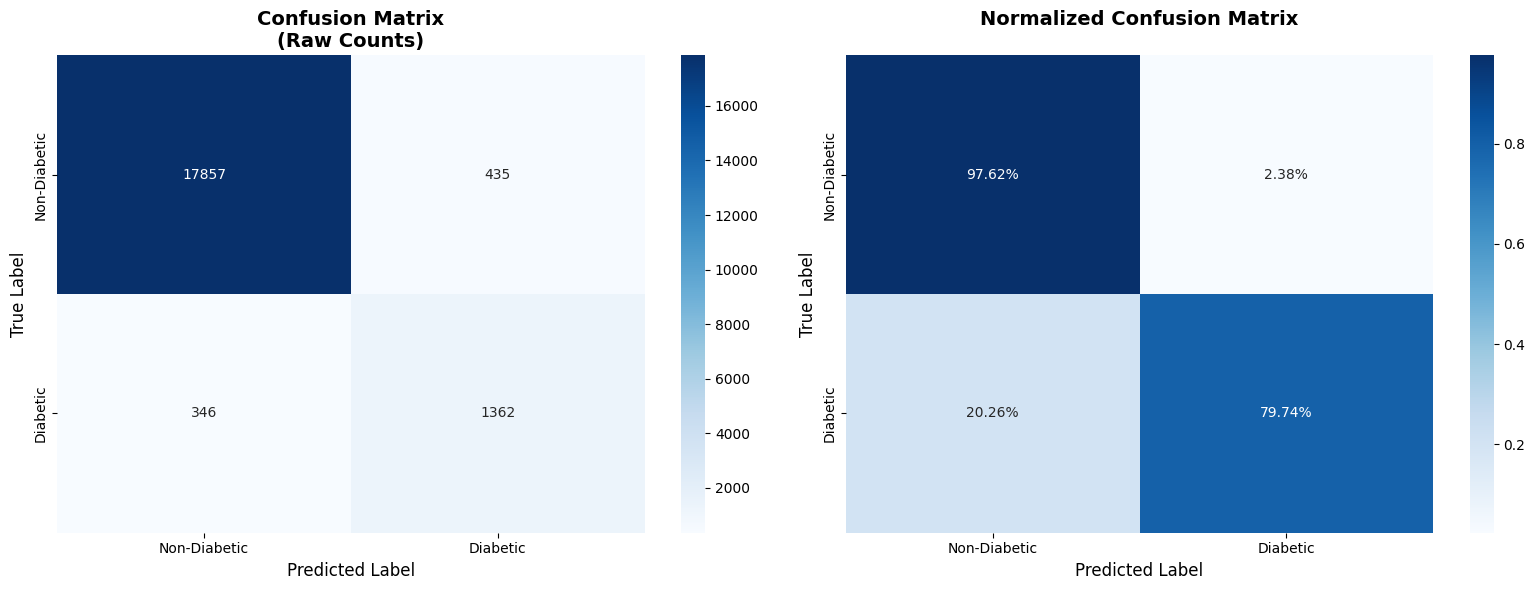

In [ ]:
ypred = best_models['XGBoost'].predict_proba(x_test_new)[:,-1]
ypred_best = (ypred >= 0.3).astype(int)

class_names = ['Non-Diabetic','Diabetic']
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,6))

cm1 = confusion_matrix(y_test,ypred_best)
sns.heatmap(cm1,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names,ax=ax1)
ax1.set_title("Confusion Matrix\n(Raw Counts)",fontsize=14,fontweight='bold')
ax1.set_ylabel("True Label",fontsize=12)
ax1.set_xlabel("Predicted Label",fontsize=12)

cm2 = confusion_matrix(y_test,ypred_best,normalize='true')
sns.heatmap(cm2,annot=True,fmt='.2%',cmap='Blues',xticklabels=class_names,yticklabels=class_names,ax=ax2)
ax2.set_title("Normalized Confusion Matrix\n",fontsize=14,fontweight='bold')
ax2.set_ylabel("True Label",fontsize=12)
ax2.set_xlabel("Predicted Label",fontsize=12)

plt.tight_layout()
plt.show()

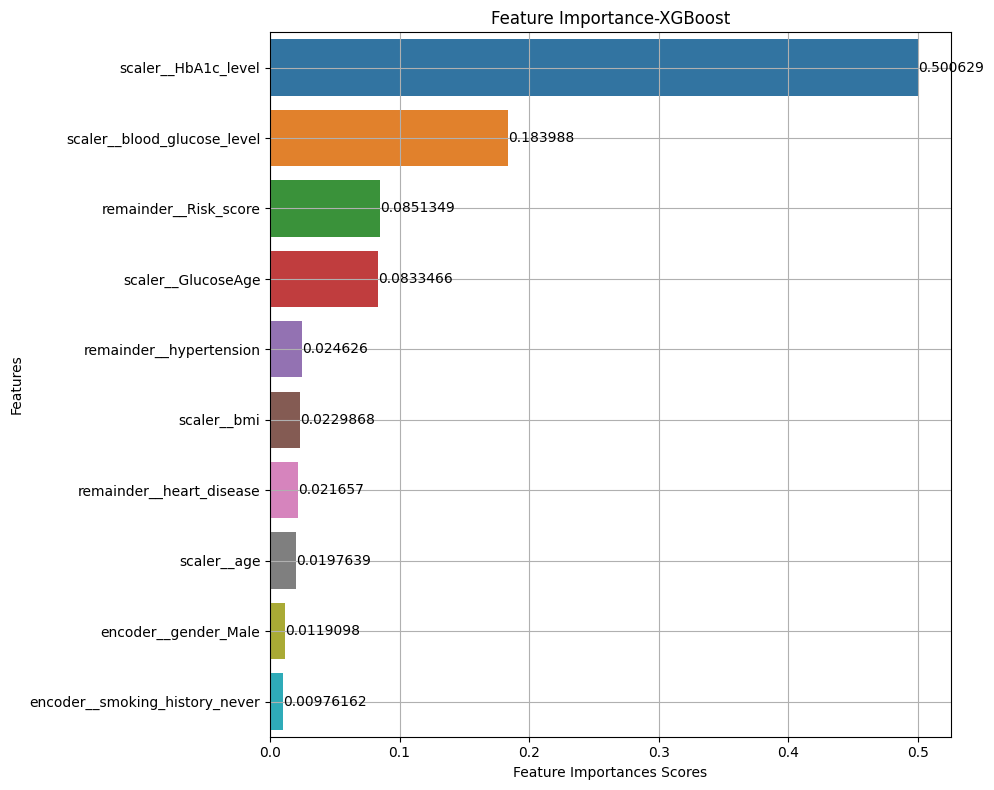

In [ ]:
feature_importances = best_models['XGBoost'].feature_importances_
feature_names = x_train_new.columns
importance_df = pd.DataFrame({
    'feature' : feature_names,
    'importance' : feature_importances
}).sort_values('importance',ascending=False).head(10)
plt.figure(figsize=(10,8))
plot = sns.barplot(data=importance_df,y='feature',x='importance',hue='feature')
for i in plot.containers :
  plot.bar_label(i)
plt.grid()
plt.title("Feature Importance-XGBoost")
plt.xlabel("Feature Importances Scores")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

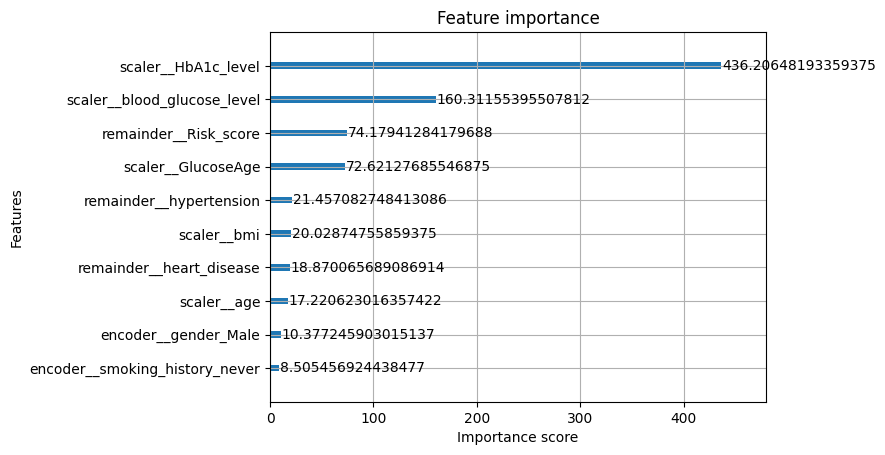

In [ ]:
from xgboost import plot_importance
plot_importance(best_models['XGBoost'],max_num_features=10,importance_type='gain')
plt.show()

#📌Conclusion :
  **This project developed a diabetes risk prediction pipeline using a large-scale diabetes prediction dataset(100k records), focusing on the trade-off between class imbalance and model reliability.**

  **Feature engineering(e.g., Risk_Score, GlucoseAge) and a comparison of cost-sensitive learning(Version B) versus SMOTE-NC(Version A) demonstrated that preserving original data distribution yields more stable performance.**

  **The Final XGBoost model achieved a PR-AUC of 0.89 and an F1-score of 0.78, outperforming balanced-data approaches while maintaining a strong precision(0.76)-recall(0.80) trade-off. A minimal train-test gap(<0.003) further indicates strong generalization with low risk of overfitting or data leakage.**